# Verifoto Training Pipeline
## Complete workflow: GitHub → Colab → Training → Results → GitHub



**Workflow:**
1. Configure experiment parameters
2. Setup environment and load data
3. Train model
4. Analyze and visualize results
5. Backup to Drive and push to GitHub

In [ ]:
# ============================================================================
# EXPERIMENT CONFIGURATION - Edit these for each run
# ============================================================================

EXPERIMENT_NAME = "2026-02-18_convnext_v7_noLeakage"  # Unique name for this experiment
DATASET_NAME = "exp_3_augmented_v6.2_noK"     # Dataset folder name in Drive
CONFIG_FILE = "convnext_v7_improved.yaml"                  # Config file to use (in configs/)

# Optional: GitHub token for pushing results (leave empty to skip push)
GITHUB_TOKEN = ""  # Your GitHub PAT (or leave empty and paste when prompted)

# ============================================================================
# Derived paths (don't edit)
# ============================================================================
DATASET_ROOT = f"/content/drive/MyDrive/DatasetVerifoto/images/{DATASET_NAME}"
CHECKPOINT_DIR = "/content/drive/MyDrive/verifoto_checkpoints"
BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXPERIMENT_NAME}"
OUTPUT_DIR = f"outputs/runs/{EXPERIMENT_NAME}"
CONFIG_PATH = f"configs/{CONFIG_FILE}"

print("✓ Experiment configured:")
print(f"  Name: {EXPERIMENT_NAME}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Config: {CONFIG_FILE}")


✓ Experiment configured:
  Name: 2026-02-18_convnext_v7_noLeakage
  Dataset: exp_3_augmented_v6.2_noK
  Config: convnext_v7_improved.yaml


---
## 🔧 ENVIRONMENT SETUP


In [9]:
# Check GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  WARNING: No GPU detected! Training will be very slow!")


GPU Available: True
GPU Name: NVIDIA A100-SXM4-40GB
GPU Memory: 42.41 GB


In [10]:
# Clone repository and install dependencies
%cd /content
!git clone https://github.com/valerio-lorenti-ai/verifoto-dl.git
%cd verifoto-dl
!git pull  # Get latest changes
!pip install -q -r requirements.txt
print("\n✓ Repository cloned and dependencies installed")


/content
fatal: destination path 'verifoto-dl' already exists and is not an empty directory.
/content/verifoto-dl
Already up to date.

✓ Repository cloned and dependencies installed


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted")

Mounted at /content/drive
✓ Google Drive mounted


---
## 📊 DATA VERIFICATION


In [11]:
# Verify dataset exists and has correct structure
import os
from pathlib import Path

print(f"Checking dataset: {DATASET_ROOT}")
print(f"Dataset exists: {os.path.exists(DATASET_ROOT)}")

if os.path.exists(DATASET_ROOT):
    contents = os.listdir(DATASET_ROOT)
    print(f"\nContents: {contents}")

    # Check required folders
    has_originali = "originali" in contents
    has_modificate = "modificate" in contents

    print(f"\n{'✓' if has_originali else '✗'} originali/")
    print(f"{'✓' if has_modificate else '✗'} modificate/")

    if has_originali and has_modificate:
        # Count images
        n_orig = len(list(Path(DATASET_ROOT, "originali").rglob("*.jpg")))
        n_mod = len(list(Path(DATASET_ROOT, "modificate").rglob("*.jpg")))
        print(f"\nImages found:")
        print(f"  Originali: {n_orig}")
        print(f"  Modificate: {n_mod}")
        print(f"  Total: {n_orig + n_mod}")
    else:
        print("\n❌ ERROR: Missing required folders!")
else:
    print("\n❌ ERROR: Dataset not found!")
    print("Check DATASET_NAME in configuration cell.")


Checking dataset: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK
Dataset exists: True

Contents: ['modificate', 'originali']

✓ originali/
✓ modificate/

Images found:
  Originali: 1432
  Modificate: 2656
  Total: 4088


In [12]:
# Update config file with correct dataset path and split strategy
import yaml

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

config['dataset_root'] = DATASET_ROOT

# Enable domain-aware split (prevents data leakage + balances source/generator)
# Set to 'group_v6' to use old split strategy (default)
config['split_strategy'] = 'domain_aware'  # 'group_v6' or 'domain_aware'
config['split_include_food'] = False       # Set True to also stratify by food_category

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(config, f)

print(f"✓ Config updated: {CONFIG_PATH}")
print(f"  dataset_root: {config['dataset_root']}")
print(f"  split_strategy: {config.get('split_strategy', 'group_v6')}")
print(f"  split_include_food: {config.get('split_include_food', False)}")


✓ Config updated: configs/convnext_v7_improved.yaml
  dataset_root: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK


---
## 🚀 TRAINING


In [13]:
# Train model
!python -m src.train_v7 \
  --config {CONFIG_PATH} \
  --run_name {EXPERIMENT_NAME} \
  --checkpoint_dir {CHECKPOINT_DIR}

print(f"\n✓ Training complete!")
print(f"  Results: {OUTPUT_DIR}")
print(f"  Checkpoint: {CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt")


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Dataset: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK
Output: outputs/runs/2026-02-18_convnext_v7_noLeakage
Checkpoints: /content/drive/MyDrive/verifoto_checkpoints/2026-02-18_convnext_v7_noLeakage

=== Loading dataset ===
                                                           
Dataset caricato: 4088 immagini
  - Originali (label=0): 1432
  - Modificate (label=1): 2656
  - Food categories: 13
  - Defect types: 6
  - Generators: 2

⚠️  Using GROUP-BASED split to prevent data leakage

GROUP-BASED SPLIT (No Data Leakage)
Unique photos: 510
  Train: 356 photos (2856 images, 0.653 pos rate)
  Val:   77 photos (616 images, 0.675 pos rate)
  Test:  77 photos (616 images, 0.610 pos rate)
✓ No overlap verified - data leakage prevented
✓ Using differential augmentation (stronger for real images)
model.safetensors: 100% 114M/114M [00:01<00:00, 66.8MB/s]

=== Model: convnext_tiny ===
Parameters: 27,820,897 (27.8M)

=== Loss: wei

---
## 📈 RESULTS ANALYSIS


In [16]:
# Run detailed analysis
!python scripts/analyze_results.py {EXPERIMENT_NAME}



Analyzing run: 2026-02-18_convnext_v7_noLeakage
Directory: outputs/runs/2026-02-18_convnext_v7_noLeakage

SUMMARY
Total samples: 616
Correct: 428 (69.48%)
Errors: 188 (30.52%)

By source:
  originali: 240 samples, 63.33% accuracy
  modificate: 376 samples, 73.40% accuracy

No food metrics found

No defect metrics found

GENERATOR COMPARISON

Generator                  Samples     F1  Precision   Recall
--------------------------------------------------------------------------------
gpt_image_1_mini               192  0.979      1.000    0.958
gpt_image_1_5                  184  0.667      1.000    0.500

⚠️  Most challenging generator: gpt_image_1_5 (F1=0.667)

METRICS BY QUALITY

Group                      Samples     F1   Prec    Rec    FP    FN
--------------------------------------------------------------------------------
buono                          216  0.000  0.000  0.000    88     0
cattivo                         24  0.000  0.000  0.000     0     0

⚠️  Problematic groups 

TEST METRICS
            acc: 0.6948
           prec: 0.7582
            rec: 0.7340
             f1: 0.7459
     prec_macro: 0.6807
      rec_macro: 0.6837
       f1_macro: 0.6819
        roc_auc: 0.8335
         pr_auc: 0.8998

CONFUSION MATRIX
              Predicted
              NON_FRODE  FRODE
True NON_FRODE     152       88   (FP: 88)
True FRODE         100      276   (FN: 100)

VISUALIZATIONS

Confusion Matrix:


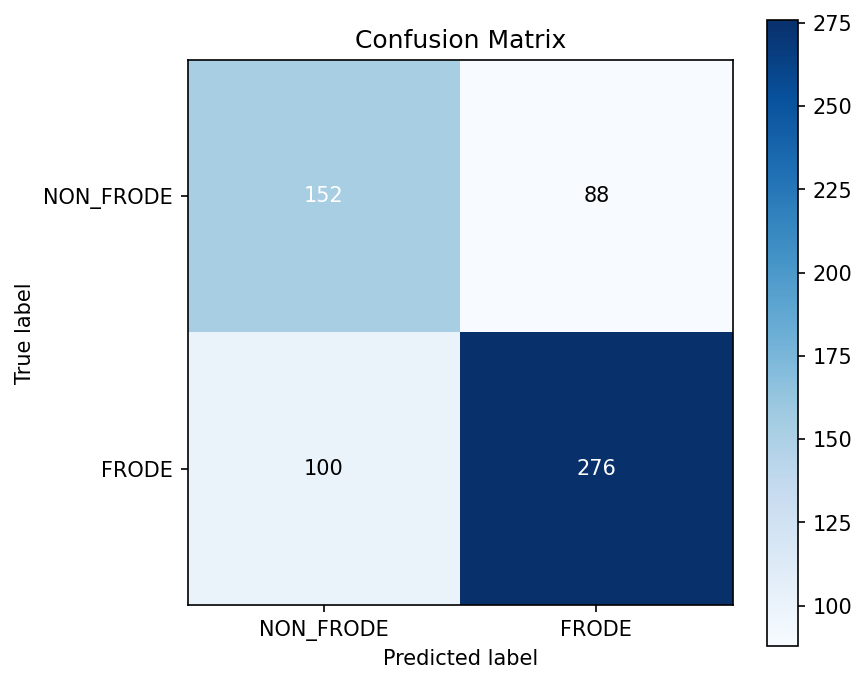


Probability Distributions:


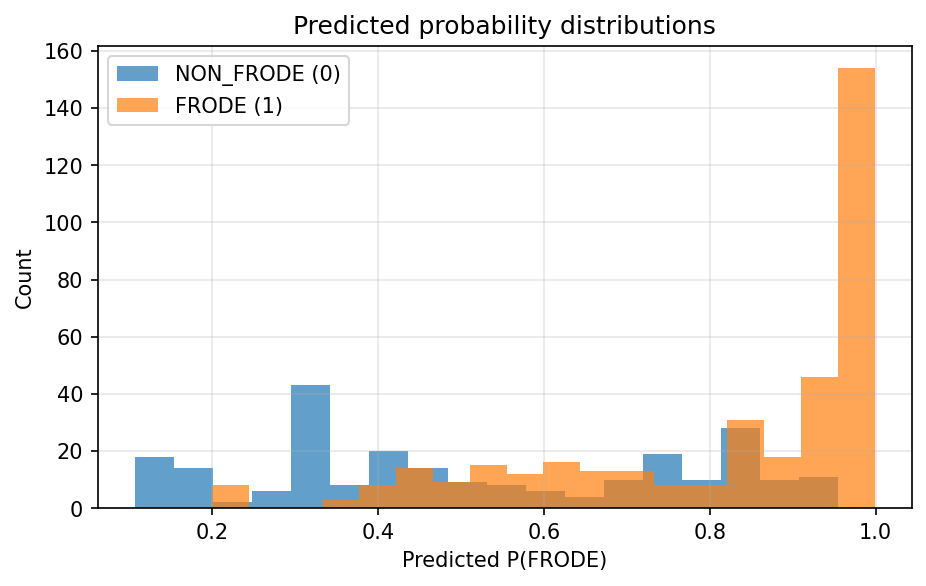


ROC Curve:


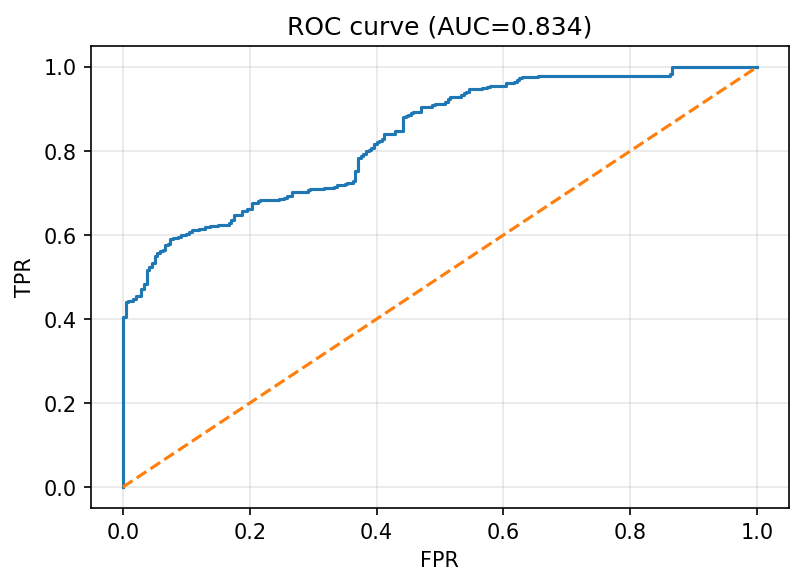


Precision-Recall Curve:


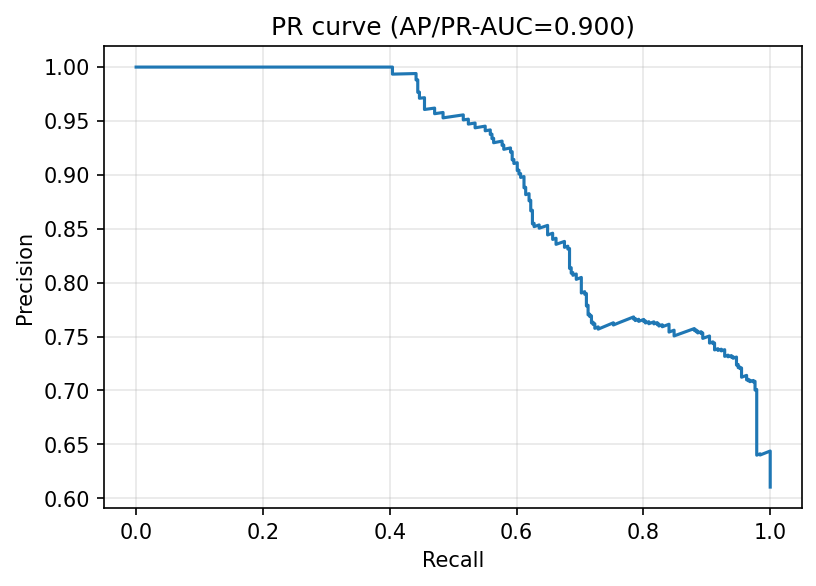

In [17]:
# Display metrics and visualizations inline
import json
import pandas as pd
from IPython.display import Image, display
from pathlib import Path

results_dir = Path(OUTPUT_DIR)

# Load metrics
with open(results_dir / "metrics.json") as f:
    metrics = json.load(f)

print("="*80)
print("TEST METRICS")
print("="*80)
for k, v in metrics['test_metrics'].items():
    if v is not None:
        print(f"{k:>15}: {v:.4f}")

# Confusion matrix
cm = metrics['confusion_matrix']
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)
print("              Predicted")
print("              NON_FRODE  FRODE")
print(f"True NON_FRODE    {cm[0][0]:>4}     {cm[0][1]:>4}   (FP: {cm[0][1]})")
print(f"True FRODE        {cm[1][0]:>4}     {cm[1][1]:>4}   (FN: {cm[1][0]})")

# Display plots
print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)

print("\nConfusion Matrix:")
display(Image(filename=str(results_dir / "cm.png")))

print("\nProbability Distributions:")
display(Image(filename=str(results_dir / "prob_dist.png")))

print("\nROC Curve:")
display(Image(filename=str(results_dir / "roc_curve.png")))

print("\nPrecision-Recall Curve:")
display(Image(filename=str(results_dir / "pr_curve.png")))


In [18]:
# Show performance by food category
food_metrics = pd.read_csv(results_dir / "group_metrics_food.csv")
food_sorted = food_metrics.sort_values('f1', ascending=False)

print("="*80)
print("PERFORMANCE BY FOOD CATEGORY")
print("="*80)
print(f"\n{'Food Category':<20} {'Samples':>8} {'F1':>6} {'Prec':>6} {'Rec':>6}")
print("-"*80)
for _, row in food_sorted.iterrows():
    print(f"{str(row['food_category']):<20} {row['n_samples']:>8} "
          f"{row['f1']:>6.3f} {row['precision']:>6.3f} {row['recall']:>6.3f}")

# Problematic categories
print("\n⚠️  Categories with F1 < 0.85:")
low_f1 = food_sorted[food_sorted['f1'] < 0.85]
if len(low_f1) > 0:
    for _, row in low_f1.iterrows():
        print(f"  - {row['food_category']}: F1={row['f1']:.3f}, "
              f"FP={int(row['fp'])}, FN={int(row['fn'])}")
else:
    print("  None! All categories have F1 >= 0.85 ✓")


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_food.csv'

In [19]:
# Show generator comparison
gen_metrics = pd.read_csv(results_dir / "group_metrics_generator.csv")

print("="*80)
print("GENERATOR COMPARISON")
print("="*80)
print(f"\n{'Generator':<25} {'Samples':>8} {'F1':>6} {'Precision':>10} {'Recall':>8}")
print("-"*80)
for _, row in gen_metrics.iterrows():
    print(f"{str(row['generator']):<25} {row['n_samples']:>8} "
          f"{row['f1']:>6.3f} {row['precision']:>10.3f} {row['recall']:>8.3f}")


GENERATOR COMPARISON

Generator                  Samples     F1  Precision   Recall
--------------------------------------------------------------------------------
gpt_image_1_mini               192  0.979      1.000    0.958
gpt_image_1_5                  184  0.667      1.000    0.500


In [20]:
# Show top false positives
fp = pd.read_csv(results_dir / "top_false_positives.csv")

print("="*80)
print("TOP 10 FALSE POSITIVES (Originali classified as Frodi)")
print("="*80)
print(f"\n{'Food':<15} {'Quality':<10} {'Defect':<15} {'Confidence':>10}")
print("-"*80)
for _, row in fp.head(10).iterrows():
    food = str(row.get('food_category', 'N/A'))[:14]
    quality = str(row.get('quality', 'N/A'))[:9]
    defect = str(row.get('defect_type', 'N/A'))[:14]
    conf = row['y_prob']
    print(f"{food:<15} {quality:<10} {defect:<15} {conf:>10.3f}")


TOP 10 FALSE POSITIVES (Originali classified as Frodi)

Food            Quality    Defect          Confidence
--------------------------------------------------------------------------------
carne           buono      nan                  0.955
altro           buono      nan                  0.949
altro           buono      nan                  0.948
altro           buono      nan                  0.948
altro           buono      nan                  0.948
altro           buono      nan                  0.946
altro           buono      nan                  0.945
altro           buono      nan                  0.940
altro           buono      nan                  0.936
carne           buono      nan                  0.922


In [21]:
# ============================================================================
# PHOTO-LEVEL ANALYSIS - Aggregate 8 versions per photo
# ============================================================================

#Cosa fa:

#Aggrega le 8 versioni per ogni foto (metriche più realistiche)
#Trova il threshold ottimale (probabilmente 0.850)
#Mostra il miglioramento rispetto al threshold di default (0.550)
#Analizza la consistenza delle predizioni tra versioni


print("="*80)
print("PHOTO-LEVEL ANALYSIS")
print("="*80)

!python scripts/analyze_by_photo.py \
    --run {OUTPUT_DIR} \
    --min-recall 0.90

# Display chosen threshold
import json
with open(f"{OUTPUT_DIR}/chosen_threshold.json", 'r') as f:
    threshold_info = json.load(f)

print("\n" + "="*80)
print("THRESHOLD RECOMMENDATION")
print("="*80)
print(f"🎯 Recommended threshold: {threshold_info['recommendation']:.3f}")
print(f"   F1-optimal threshold: {threshold_info['f1_optimal']:.3f}")
print(f"   Precision-optimal (recall≥90%): {threshold_info['precision_optimal_recall_90']:.3f}")
print(f"\nRationale: {threshold_info['rationale']}")

# Display photo-level metrics
with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

print("\n" + "="*80)
print("PHOTO-LEVEL METRICS (aggregated by photo)")
print("="*80)
print(f"Total photos: {photo_metrics['n_photos']}")

print("\nOriginal threshold (0.550):")
orig = photo_metrics['original_threshold']
print(f"  Precision: {orig['precision']:.1%}")
print(f"  Recall:    {orig['recall']:.1%}")
print(f"  F1:        {orig['f1']:.1%}")
print(f"  FP: {orig['fp']}, FN: {orig['fn']}")

print(f"\nOptimal threshold ({threshold_info['recommendation']:.3f}):")
opt = photo_metrics['optimal_f1_threshold']
print(f"  Precision: {opt['precision']:.1%} ({opt['precision']-orig['precision']:+.1%})")
print(f"  Recall:    {opt['recall']:.1%} ({opt['recall']-orig['recall']:+.1%})")
print(f"  F1:        {opt['f1']:.1%} ({opt['f1']-orig['f1']:+.1%})")
print(f"  FP: {opt['fp']} ({int(opt['fp']-orig['fp']):+d}), FN: {opt['fn']} ({int(opt['fn']-orig['fn']):+d})")

print("\nConsistency (std of 8 versions per photo):")
cons = photo_metrics['consistency']
print(f"  Photos with std < 0.05: {cons['pct_std_lt_0.05']:.1f}%")
print(f"  Median std: {cons['median_std']:.6f}")
print(f"  Average std: {cons['avg_std']:.4f}")

print("\n✓ Photo-level analysis complete")


PHOTO-LEVEL ANALYSIS
PHOTO-LEVEL ANALYSIS
Run: 2026-02-18_convnext_v7_noLeakage
Aggregation: mean

Image-level: 616 images
Original threshold: 0.700

AGGREGATING BY PHOTO
Photo-level: 77 unique photos
  Positive: 47
  Negative: 30
  Avg versions per photo: 8.00

METRICS AT ORIGINAL THRESHOLD (0.700)

Photo-level metrics:
  Accuracy:  0.6753
  Precision: 0.7500
  Recall:    0.7021
  F1:        0.7253
  ROC-AUC:   0.8355
  PR-AUC:    0.9018

Confusion Matrix:
  TN=19  FP=11
  FN=14  TP=33

THRESHOLD OPTIMIZATION

Optimal threshold (F1): 0.350
  F1: 0.8214
  Accuracy:  0.7403
  Precision: 0.7077
  Recall:    0.9787
  FP: 19, FN: 1

Precision-optimized threshold (recall >= 0.90): 0.450
  Precision: 0.7414
  Recall:    0.9149
  F1:        0.8190
  FP: 15, FN: 4

CONSISTENCY ANALYSIS

Probability std across versions:
  Mean:   0.0173
  Median: 0.0106
  Max:    0.1283

Photos with low variance:
  std < 0.01: 37 (48.1%)
  std < 0.02: 52 (67.5%)
  std < 0.05: 71 (92.2%)

HARD CASES

False Posit

In [22]:
# ============================================================================
# TEMPERATURE SCALING CALIBRATION - Reduce overconfidence
# ============================================================================
print("="*80)
print("TEMPERATURE SCALING CALIBRATION")
print("="*80)

!python scripts/apply_calibration.py \
    --run {OUTPUT_DIR}

# Display calibration results
import json

# Load temperature from calibration_T.json
with open(f"{OUTPUT_DIR}/calibration_T.json", 'r') as f:
    cal_T = json.load(f)

# Load report from calibration_report.json
with open(f"{OUTPUT_DIR}/calibration_report.json", 'r') as f:
    cal_report = json.load(f)

print("\n" + "="*80)
print("CALIBRATION RESULTS")
print("="*80)
print(f"📊 Optimal temperature: T = {cal_T['temperature']:.4f}")

print("\nExpected Calibration Error (lower is better):")
print(f"  Before calibration: {cal_report['ece_before']:.4f}")
print(f"  After calibration:  {cal_report['ece_after']:.4f}")
print(f"  Improvement: {cal_report['ece_improvement']:.4f}")

print("\nOverconfident negatives (prob>0.95 but y=0):")
print(f"  Before: {cal_report['overconfident_negatives_before']}")
print(f"  After:  {cal_report['overconfident_negatives_after']}")
print(f"  Reduction: {cal_report['overconfident_negatives_before'] - cal_report['overconfident_negatives_after']}")

# Display updated photo-level metrics
with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

print("\n" + "="*80)
print("PHOTO-LEVEL METRICS (after calibration)")
print("="*80)

with open(f"{OUTPUT_DIR}/chosen_threshold.json", 'r') as f:
    threshold_info = json.load(f)

print(f"Updated threshold: {threshold_info['recommendation']:.3f}")

opt = photo_metrics['optimal_f1_threshold']
print(f"\nCalibrated metrics:")
print(f"  Precision: {opt['precision']:.1%}")
print(f"  Recall:    {opt['recall']:.1%}")
print(f"  F1:        {opt['f1']:.1%}")
print(f"  FP: {opt['fp']}, FN: {opt['fn']}")

print("\n✓ Calibration complete")


TEMPERATURE SCALING CALIBRATION
TEMPERATURE SCALING CALIBRATION
Run: 2026-02-18_convnext_v7_noLeakage

Loading validation data...
  Validation samples: 616

Optimizing temperature...

Temperature Calibration:
  Initial T: 1.0000
  Optimal T: 1.0000
  NLL (before): 0.3856
  NLL (after):  0.3856

✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_T.json

Applying calibration to test set...

Calibration Report:
  ECE before: 0.1327
  ECE after:  0.1327
  Improvement: 0.0000

  Overconfident negatives (prob>0.95 but y=0):
    Before: 1
    After:  1
    Reduction: 0

✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/predictions_calibrated.csv
✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_report.json

RE-RUNNING PHOTO-LEVEL ANALYSIS WITH CALIBRATED PROBABILITIES
PHOTO-LEVEL ANALYSIS
Run: 2026-02-18_convnext_v7_noLeakage
Aggregation: mean

Image-level: 616 images
Original threshold: 0.700

AGGREGATING BY PHOTO
Photo-level: 77 unique photos
  Positive

In [29]:
# ============================================================================
# HARD NEGATIVE FINE-TUNING (OPTIONAL - only if precision < 75%)
# ============================================================================
print("="*80)
print("HARD NEGATIVE FINE-TUNING CHECK")
print("="*80)

# Check if we need hard negative mining
import json
import os

with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

current_precision = photo_metrics['optimal_f1_threshold']['precision']
print(f"Current precision: {current_precision:.1%}")

PRECISION_THRESHOLD = 0.75
RUN_HARD_NEGATIVE = current_precision < PRECISION_THRESHOLD

if RUN_HARD_NEGATIVE:
    print(f"\n⚠️  Precision < {PRECISION_THRESHOLD:.0%} → Running hard negative fine-tuning")
    print("This will fine-tune on 17 problematic photos (systematic FPs)")

    # Run hard negative mining
    !python scripts/hard_negative_finetune.py \
        --run {OUTPUT_DIR} \
        --config {CONFIG_PATH} \
        --checkpoint_dir {CHECKPOINT_DIR} \
        --epochs 5 \
        --lr 1e-5 \
        --repeat_factor 3

    # New run name
    HN_RUN_NAME = f"{EXPERIMENT_NAME}_hard_negative"
    HN_OUTPUT_DIR = f"outputs/runs/{HN_RUN_NAME}"

    # Check if hard negative training completed
    if os.path.exists(f"{HN_OUTPUT_DIR}/photo_level_metrics.json"):
        print("\n" + "="*80)
        print("HARD NEGATIVE RESULTS")
        print("="*80)

        # Display comparison
        with open(f"{HN_OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
            hn_metrics = json.load(f)

        hn_opt = hn_metrics['optimal_f1_threshold']

        print(f"\nBefore hard negative mining:")
        print(f"  Precision: {current_precision:.1%}")
        print(f"  Recall:    {photo_metrics['optimal_f1_threshold']['recall']:.1%}")
        print(f"  F1:        {photo_metrics['optimal_f1_threshold']['f1']:.1%}")

        print(f"\nAfter hard negative mining:")
        print(f"  Precision: {hn_opt['precision']:.1%} ({hn_opt['precision']-current_precision:+.1%})")
        print(f"  Recall:    {hn_opt['recall']:.1%}")
        print(f"  F1:        {hn_opt['f1']:.1%}")

        print(f"\n✓ Hard negative fine-tuning complete")
        print(f"  New run: {HN_OUTPUT_DIR}")

        # Update backup directory
        HN_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{HN_RUN_NAME}"
    else:
        print(f"\n❌ Hard negative fine-tuning failed - check errors above")
        HN_RUN_NAME = None
        HN_OUTPUT_DIR = None
        HN_BACKUP_DIR = None
else:
    print(f"\n✓ Precision ≥ {PRECISION_THRESHOLD:.0%} → Skipping hard negative fine-tuning")
    print("Model performance is already good enough!")
    HN_RUN_NAME = None
    HN_OUTPUT_DIR = None
    HN_BACKUP_DIR = None

print("\n" + "="*80)


HARD NEGATIVE FINE-TUNING CHECK
Current precision: 70.8%

⚠️  Precision < 75% → Running hard negative fine-tuning
This will fine-tune on 17 problematic photos (systematic FPs)
usage: hard_negative_finetune.py [-h] --run RUN --config CONFIG
                                 [--epochs EPOCHS] [--lr LR]
                                 [--repeat_factor REPEAT_FACTOR]
                                 [--output_suffix OUTPUT_SUFFIX]
hard_negative_finetune.py: error: unrecognized arguments: --checkpoint_dir /content/drive/MyDrive/verifoto_checkpoints

❌ Hard negative fine-tuning failed - check errors above



---
## 💾 BACKUP & SYNC


In [23]:
# ============================================================================
# BACKUP RESULTS TO GOOGLE DRIVE
# ============================================================================
import shutil

print("="*80)
print("BACKING UP RESULTS TO DRIVE")
print("="*80)

# Backup main run
print(f"\nBacking up main run: {BACKUP_DIR}")
!mkdir -p {BACKUP_DIR}
!cp -r {OUTPUT_DIR}/* {BACKUP_DIR}/
print("✓ Main run backup complete")

# Backup hard negative run if it exists
if 'HN_BACKUP_DIR' in locals() and HN_BACKUP_DIR is not None:
    print(f"\nBacking up hard negative run: {HN_BACKUP_DIR}")
    !mkdir -p {HN_BACKUP_DIR}
    !cp -r {HN_OUTPUT_DIR}/* {HN_BACKUP_DIR}/
    print("✓ Hard negative run backup complete")

print("\n✓ All backups complete")



BACKING UP RESULTS TO DRIVE

Backing up main run: /content/drive/MyDrive/verifoto_results/2026-02-18_convnext_v7_noLeakage
✓ Main run backup complete

✓ All backups complete


# Test con dataset esterno - AntiLeakage

In [24]:
# ============================================================================
# EXTERNAL TEST - Test su dataset holdout
# ============================================================================
EXTERNAL_DATASET = "/content/drive/MyDrive/DatasetVerifoto/images/whatsapp_Luca"

print("="*80)
print("EXTERNAL TEST")
print("="*80)

# Assicurati di essere nella directory corretta
%cd /content/verifoto-dl

# Ottieni threshold ottimale dal training
import json
import os

with open(f"{OUTPUT_DIR}/metrics.json", 'r') as f:
    train_metrics = json.load(f)
optimal_threshold = train_metrics.get('threshold', 0.5)

EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"

print(f"External dataset: {EXTERNAL_DATASET}")
print(f"Threshold: {optimal_threshold:.3f}")
print(f"Run name: {EXTERNAL_RUN_NAME}")

# Run external test
!python -m src.eval \
    --config {CONFIG_PATH} \
    --run_name {EXTERNAL_RUN_NAME} \
    --checkpoint_path {CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt \
    --threshold {optimal_threshold} \
    --external_test_dataset {EXTERNAL_DATASET}

# Verifica che il test sia completato
if os.path.exists(f"outputs/runs/{EXTERNAL_RUN_NAME}/metrics.json"):
    # Backup
    EXTERNAL_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXTERNAL_RUN_NAME}"
    !mkdir -p {EXTERNAL_BACKUP_DIR}
    !cp -r outputs/runs/{EXTERNAL_RUN_NAME}/* {EXTERNAL_BACKUP_DIR}/

    print(f"\n✓ External test complete: outputs/runs/{EXTERNAL_RUN_NAME}")
    print(f"✓ Backup saved to: {EXTERNAL_BACKUP_DIR}")
else:
    print(f"\n❌ External test failed - check errors above")


EXTERNAL TEST
/content/verifoto-dl
External dataset: /content/drive/MyDrive/DatasetVerifoto/images/whatsapp_Luca
Threshold: 0.700
Run name: 2026-02-18_convnext_v7_noLeakage_external
Device: cuda
Checkpoint: /content/drive/MyDrive/verifoto_checkpoints/2026-02-18_convnext_v7_noLeakage/best.pt
Output: outputs/runs/2026-02-18_convnext_v7_noLeakage_external

EXTERNAL TEST MODE
External test dataset: /content/drive/MyDrive/DatasetVerifoto/images/whatsapp_Luca
⚠️  This dataset is COMPLETELY SEPARATE from training data
   No internal split - using entire dataset as test set
                                            
Dataset caricato: 77 immagini
  - Originali (label=0): 61
  - Modificate (label=1): 16
  - Food categories: 13
  - Defect types: 10
  - Generators: 8

External test set: 77 images
  Originali (label=0): 61
  Modificate (label=1): 16
Loaded checkpoint from /content/drive/MyDrive/verifoto_checkpoints/2026-02-18_convnext_v7_noLeakage/best.pt

=== Evaluation (threshold=0.700000000000

In [25]:
# ============================================================================
# PUSH RESULTS TO GITHUB
# ============================================================================
import os
from getpass import getpass

# Get GitHub token if not set
if not GITHUB_TOKEN:
    print("GitHub token not set in configuration.")
    GITHUB_TOKEN = getpass("Enter your GitHub Personal Access Token (or press Enter to skip): ")

if GITHUB_TOKEN:
    %cd /content/verifoto-dl

    # Configure git
    !git config user.email "colab@verifoto.ai"
    !git config user.name "Colab Training"

    # Add main run results (force to override .gitignore)
    !git add -f {OUTPUT_DIR}

    # Add hard negative run if it exists
    if 'HN_OUTPUT_DIR' in locals() and HN_OUTPUT_DIR is not None:
        !git add -f {HN_OUTPUT_DIR}

    # Add external test results
    EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"
    if os.path.exists(f"outputs/runs/{EXTERNAL_RUN_NAME}"):
        !git add -f outputs/runs/{EXTERNAL_RUN_NAME}


    # Commit
    if 'HN_RUN_NAME' in locals() and HN_RUN_NAME is not None:
        commit_msg = f"Add training results: {EXPERIMENT_NAME} + {HN_RUN_NAME}"
    else:
        commit_msg = f"Add training results: {EXPERIMENT_NAME}"

    !git commit -m "{commit_msg}"

    # Push
    repo_url = f"https://{GITHUB_TOKEN}@github.com/valerio-lorenti-ai/verifoto-dl.git"
    !git push {repo_url} main

    print("\n✓ Results pushed to GitHub")
    print(f"  Main run: {OUTPUT_DIR}")
    if 'HN_OUTPUT_DIR' in locals() and HN_OUTPUT_DIR is not None:
        print(f"  Hard negative run: {HN_OUTPUT_DIR}")
else:
    print("\n⚠️  Skipping GitHub push (no token provided)")
    print("Results are backed up to Drive and available locally.")



/content/verifoto-dl
[main f4f4a49] Add training results: 2026-02-18_convnext_v7_noLeakage
 38 files changed, 2552 insertions(+)
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_T.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_report.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/chosen_threshold.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/cm.png
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_defect_type.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_food_category.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_generator.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_quality.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/metrics.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/notes.md
 

---
## ✅ COMPLETION SUMMARY


In [26]:
# ============================================================================
# TRAINING PIPELINE COMPLETE
# ============================================================================
import os

print("="*80)
print("TRAINING PIPELINE COMPLETE")
print("="*80)

print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Dataset: {DATASET_NAME}")

print(f"\nResults locations:")
print(f"  Local: {OUTPUT_DIR}")
print(f"  Drive backup: {BACKUP_DIR}")
print(f"  Checkpoint: {CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt")

# Check if external test was run
EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"
EXTERNAL_OUTPUT_DIR = f"outputs/runs/{EXTERNAL_RUN_NAME}"

if os.path.exists(EXTERNAL_OUTPUT_DIR):
    EXTERNAL_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXTERNAL_RUN_NAME}"
    print(f"\nExternal test:")
    print(f"  Local: {EXTERNAL_OUTPUT_DIR}")
    print(f"  Drive backup: {EXTERNAL_BACKUP_DIR}")

print(f"\nNext steps:")
print(f"  1. Review metrics and visualizations above")
print(f"  2. Pull results from GitHub to local machine:")
print(f"     git pull origin main")
print(f"  3. Analyze locally:")
print(f"     python scripts/analyze_results.py {EXPERIMENT_NAME}")

if os.path.exists(EXTERNAL_OUTPUT_DIR):
    print(f"  4. Compare internal vs external test:")
    print(f"     python scripts/compare_internal_external.py \\")
    print(f"       --internal outputs/runs/{EXPERIMENT_NAME} \\")
    print(f"       --external outputs/runs/{EXTERNAL_RUN_NAME}")

print("\n" + "="*80)


TRAINING PIPELINE COMPLETE

Experiment: 2026-02-18_convnext_v7_noLeakage
Dataset: exp_3_augmented_v6.2_noK

Results locations:
  Local: outputs/runs/2026-02-18_convnext_v7_noLeakage
  Drive backup: /content/drive/MyDrive/verifoto_results/2026-02-18_convnext_v7_noLeakage
  Checkpoint: /content/drive/MyDrive/verifoto_checkpoints/2026-02-18_convnext_v7_noLeakage/best.pt

External test:
  Local: outputs/runs/2026-02-18_convnext_v7_noLeakage_external
  Drive backup: /content/drive/MyDrive/verifoto_results/2026-02-18_convnext_v7_noLeakage_external

Next steps:
  1. Review metrics and visualizations above
  2. Pull results from GitHub to local machine:
     git pull origin main
  3. Analyze locally:
     python scripts/analyze_results.py 2026-02-18_convnext_v7_noLeakage
  4. Compare internal vs external test:
     python scripts/compare_internal_external.py \
       --internal outputs/runs/2026-02-18_convnext_v7_noLeakage \
       --external outputs/runs/2026-02-18_convnext_v7_noLeakage_exter